## Intro
The goal of this notebook is use different machine learning algorithms to perform binary classification for malware detection.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
# import tensorflow as tf

from matplotlib import pyplot
from sklearn.decomposition import PCA

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC

from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay, f1_score, precision_score, recall_score
from sklearn.model_selection import cross_val_score

## Data preparation and Exploratory Data Analysis (EDA)
Using pandas, we read in the data which is separated by '|' in the CSV file

In [95]:
df = pd.read_csv('MalwareData.csv', sep='|')
df.head(10)

,Name,md5,Machine,SizeOfOptionalHeader,Characteristics,MajorLinkerVersion,MinorLinkerVersion,SizeOfCode,SizeOfInitializedData,SizeOfUninitializedData,...,ResourcesNb,ResourcesMeanEntropy,ResourcesMinEntropy,ResourcesMaxEntropy,ResourcesMeanSize,ResourcesMinSize,ResourcesMaxSize,LoadConfigurationSize,VersionInformationSize,legitimate
0,memtest.exe,631ea355665f28d4707448e442fbf5b8,332,224,258,9,0,361984,115712,0,...,4,3.262823,2.568844,3.537939,8797.000000,216,18032,0,16,1
1,ose.exe,9d10f99a6712e28f8acd5641e3a7ea6b,332,224,3330,9,0,130560,19968,0,...,2,4.250461,3.420744,5.080177,837.000000,518,1156,72,18,1
2,setup.exe,4d92f518527353c0db88a70fddcfd390,332,224,3330,9,0,517120,621568,0,...,11,4.426324,2.846449,5.271813,31102.272727,104,270376,72,18,1
3,DW20.EXE,a41e524f8d45f0074fd07805ff0c9b12,332,224,258,9,0,585728,369152,0,...,10,4.364291,2.669314,6.400720,1457.000000,90,4264,72,18,1
4,dwtrig20.exe,c87e561258f2f8650cef999bf643a731,332,224,258,9,0,294912,247296,0,...,2,4.306100,3.421598,5.190603,1074.500000,849,1300,72,18,1
5,airappinstaller.exe,e6e5a0ab3b1a27127c5c4a29b237d823,332,224,258,9,0,512,46592,0,...,10,4.843545,2.718577,7.965023,3858.600000,104,14671,0,16,1
6,AcroBroker.exe,dd7d901720f71e7e4f5fb13ec973d8e9,332,224,290,9,0,222720,67072,0,...,7,3.892779,1.346314,5.232167,1629.142857,52,8648,72,16,1
7,AcroRd32.exe,540c61844ccd78c121c3ef48f3a34f0e,332,224,290,9,0,823808,650240,0,...,29,4.102636,1.664392,6.373890,11939.689655,94,270376,72,15,1
8,AcroRd32Info.exe,9afe3c62668f55b8433cde602258236e,332,224,290,9,0,4096,7168,0,...,4,5.097499,3.435993,5.929812,616.500000,94,1164,72,15,1
9,AcroTextExtractor.exe,ba621a96e44f6558c08cf25b40cb1bd4,332,224,290,9,0,29696,12800,0,...,2,4.235788,3.456169,5.015407,820.000000,716,924,72,15,1


Taking a look at the data, the first two columns are 'Name' and 'md5'. We drop these two columns as "Name' is just what the file is called and a file could be called anything whether it is malware or not. 'md5' is a hash generated for file authentication and is done for every file.

In [96]:
df = df.drop(columns=['Name', 'md5'])

We check if any rows have missing data. If so, we have to deal with the missing data. However, there is no missing data in this dataset.

In [86]:
# Check for na values
df.isna().sum()

Machine                        0
SizeOfOptionalHeader           0
Characteristics                0
MajorLinkerVersion             0
MinorLinkerVersion             0
SizeOfCode                     0
SizeOfInitializedData          0
SizeOfUninitializedData        0
AddressOfEntryPoint            0
BaseOfCode                     0
BaseOfData                     0
ImageBase                      0
SectionAlignment               0
FileAlignment                  0
MajorOperatingSystemVersion    0
MinorOperatingSystemVersion    0
MajorImageVersion              0
MinorImageVersion              0
MajorSubsystemVersion          0
MinorSubsystemVersion          0
SizeOfImage                    0
SizeOfHeaders                  0
CheckSum                       0
Subsystem                      0
DllCharacteristics             0
SizeOfStackReserve             0
SizeOfStackCommit              0
SizeOfHeapReserve              0
SizeOfHeapCommit               0
LoaderFlags                    0
NumberOfRv

Looking at the dataframe, some of the columns have the same value (Machine, SizeOfOptionalHeader), so we check to see how many unique values each column has in case a column only has one value. Each column seems to have more than one unique value, so we don't remove any columns.

In [87]:
for c in df.columns:
    print(c + ": {} unique values".format(len(df[c].unique())))

Machine: 3 unique values
SizeOfOptionalHeader: 5 unique values
Characteristics: 104 unique values
MajorLinkerVersion: 41 unique values
MinorLinkerVersion: 62 unique values
SizeOfCode: 3809 unique values
SizeOfInitializedData: 3217 unique values
SizeOfUninitializedData: 441 unique values
AddressOfEntryPoint: 23110 unique values
BaseOfCode: 385 unique values
BaseOfData: 1106 unique values
ImageBase: 9099 unique values
SectionAlignment: 12 unique values
FileAlignment: 9 unique values
MajorOperatingSystemVersion: 12 unique values
MinorOperatingSystemVersion: 12 unique values
MajorImageVersion: 38 unique values
MinorImageVersion: 70 unique values
MajorSubsystemVersion: 6 unique values
MinorSubsystemVersion: 10 unique values
SizeOfImage: 2312 unique values
SizeOfHeaders: 30 unique values
CheckSum: 81633 unique values
Subsystem: 4 unique values
DllCharacteristics: 74 unique values
SizeOfStackReserve: 40 unique values
SizeOfStackCommit: 40 unique values
SizeOfHeapReserve: 30 unique values
Size

We look at how many legitimate and malware data points we have to see if there is an imbalance of each class. There is not an imbalance between legitimate (1) and malware (0) classes.

In [88]:
df['legitimate'].value_counts()

legitimate
0    96724
1    41323
Name: count, dtype: int64

Looking at the type of each column, all of them are int or float so we do not have any categorical features.

In [89]:
df.dtypes

Machine                          int64
SizeOfOptionalHeader             int64
Characteristics                  int64
MajorLinkerVersion               int64
MinorLinkerVersion               int64
SizeOfCode                       int64
SizeOfInitializedData            int64
SizeOfUninitializedData          int64
AddressOfEntryPoint              int64
BaseOfCode                       int64
BaseOfData                       int64
ImageBase                      float64
SectionAlignment                 int64
FileAlignment                    int64
MajorOperatingSystemVersion      int64
MinorOperatingSystemVersion      int64
MajorImageVersion                int64
MinorImageVersion                int64
MajorSubsystemVersion            int64
MinorSubsystemVersion            int64
SizeOfImage                      int64
SizeOfHeaders                    int64
CheckSum                         int64
Subsystem                        int64
DllCharacteristics               int64
SizeOfStackReserve       

We separate features and the target variable and then use a Scaler to standardize the data.

In [130]:
def zscore_normalization(df1, name):
    mean = df1[name].mean()
    sd = df1[name].std()

    df1[name] = (df1[name] - mean) / sd

X = df.drop(columns=['legitimate'])

for i in X.columns:
    zscore_normalization(X, i)

y = df['legitimate']

We create two dataframes to record the accuracy, f1 score, and times taken to train and test the models.

In [91]:
accuracies = pd.DataFrame(columns=["Model", "Accuracy", "Precision", "Recall", "F1"])
times = pd.DataFrame(columns=["Model", "Train", "Test"])

Create a function to train, test, and cross-validate each model. It cross-validates the model using K-fold validation with 5 folds. It outputs the time taken to train and test the model, the accuracy and f1 score, the confusion matrix for binary classification, and the time taken to cross-validate the model.

In [92]:
def run_model(model_type, model, X_train, X_test, y_train, y_test, X, y):
    print(model_type, "classifier:") 
    
    start_time_train = time.time()  # Start time

    model.fit(X_train, y_train)  # Fit the classifier
    
    end_time_train = time.time()  # End time
    time_taken_train = end_time_train - start_time_train  # Time taken to run the code

    print(f"Time taken to train the {model_type} model: {time_taken_train} seconds")
    
    # Make predictions
    start_test = time.time()
    y_pred = model.predict(X_test)
    end_test = time.time()
    time_taken_test = end_test - start_test  # Time taken to run the code

    print(f"Time taken to test the {model_type} model: {time_taken_test} seconds")
    times.loc[len(times.index)] = [model_type,time_taken_train, time_taken_test]

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", recall)
    print("F1 score:", f1)

    accuracies.loc[len(accuracies.index)] = [model_type, acc, prec, recall, f1]
    
    cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot()
    plt.show()
    
    #Cross validation 
    start_time_cv = time.time() 
    
    cv_scores = cross_val_score(model, X, y, cv=5)
    
    end_time_cv = time.time()  # End time
    time_taken_cv = end_time_cv - start_time_cv  # Time taken to run the code

    print(f"Time taken to cross-validate the {model_type} model: {time_taken_cv} seconds")
    print("Cross-validation scores:", cv_scores)
    print("Mean CV accuracy:", cv_scores.mean())
    print("Standard deviation of CV accuracy:", cv_scores.std())

We can take a look at the correlation matrix of the data. There are several features that have high correlation with each other, which could impact our models such as logistic regression where input features should be independent of each other.

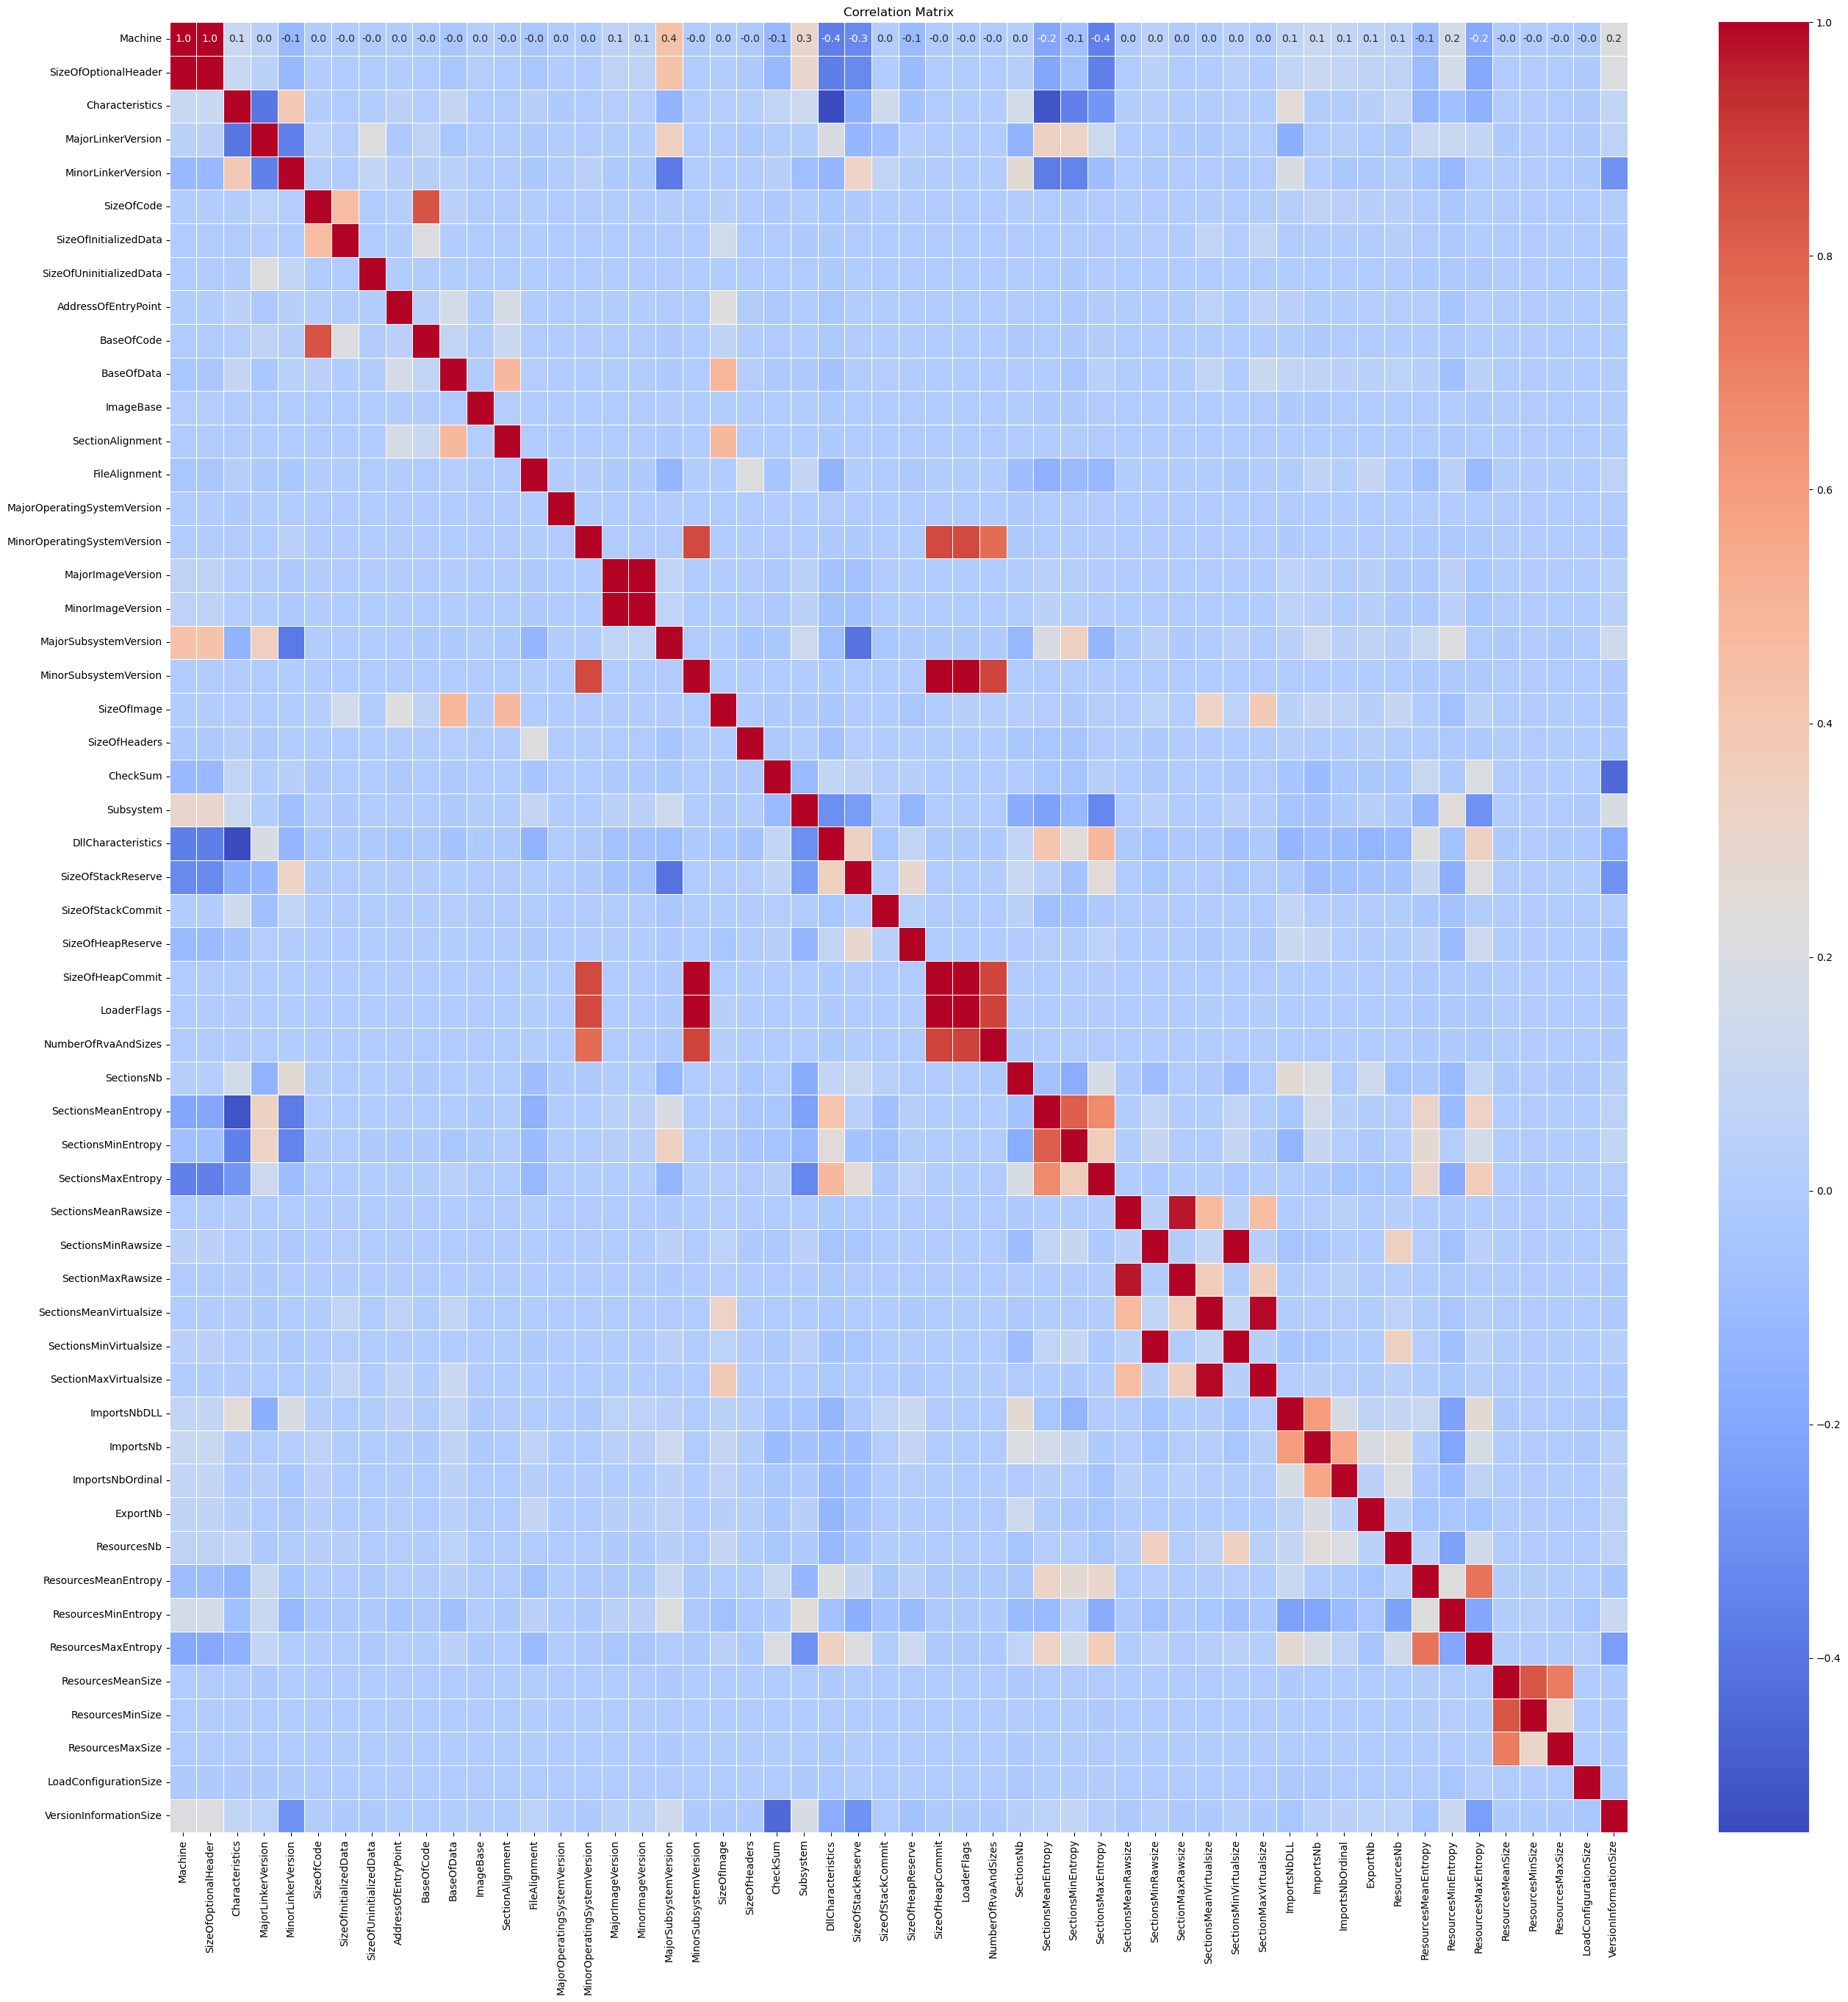

In [80]:
correlation_matrix = X.corr()
# Set up the figure size
f, ax = plt.subplots(figsize=(32, 32))
# Create a heatmap using seaborn
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidth=.5, ax=ax, fmt='.1f')
# Set the title and show the plot
plt.title('Correlation Matrix')
plt.show()

In addition, we currently have 54 features. We choose to use Principal Component Analysis (PCA) to reduce the dimensionality of the data and obtain a smaller set of uncorrelated features. By plotting the explained variance by the first k components, we can see the minimum number of components we need to cover 95% of the variance.

36

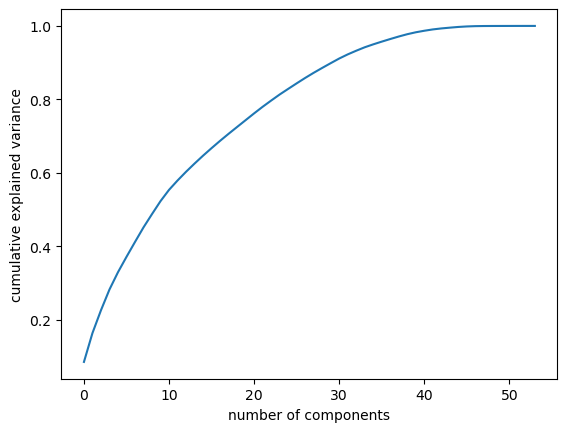

In [81]:
pca = PCA()
pca.fit(X)
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('number of components')
plt.ylabel('cumulative explained variance')
np.argmax(np.cumsum(pca.explained_variance_ratio_) >= 0.95) + 1

The number of components we should reduce our data down to is 36, so we can remove highly correlated features from our dataset.

In [102]:
cols_to_drop = []
for i in X.columns:
    for j in X.columns:
        if i != j:
            if abs(correlation_matrix[i][j]) > 0.6 and i not in cols_to_drop and j not in cols_to_drop:
                cols_to_drop.append(i)
cols_to_drop = set(cols_to_drop)
X.drop(columns=cols_to_drop, inplace=True)
print(len(X.columns))

40


We then split the data into train and test data.

In [60]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20)

## Logistic Regression
We run, train, and cross-validate a Logistic Regression model. The model is trained quickly with an accuracy of 97.8%. From the cross-validation, the Logistic Regression model does not overfit the data since the average accuracy from cross-validation is similar to the accuracy of the model.

Logistic Regression classifier:
Time taken to train the Logistic Regression model: 0.3018317222595215 seconds
Time taken to test the Logistic Regression model: 0.0054547786712646484 seconds
Accuracy: 0.978739587106121
Precision: 0.9698159509202454
Recall: 0.9586416009702851
F1 score: 0.9641964013418726


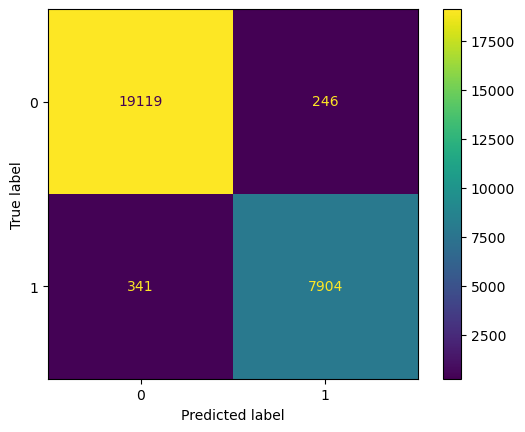

Time taken to cross-validate the Logistic Regression model: 1.6606526374816895 seconds
Cross-validation scores: [0.97580587 0.9835929  0.94867616 0.96801768 0.99036546]
Mean CV accuracy: 0.9732916121643772
Standard deviation of CV accuracy: 0.014406175115308426


In [15]:
lr_model = LogisticRegression(random_state=0, max_iter=1000)
run_model('Logistic Regression', lr_model, X_train, X_test, y_train, y_test, X, y)

## Random Forest
We run, train, and cross-validate a Random Forest model. The model took longer to train compared to the Logistic Regression model with an accuracy of 99.5%. From cross-validation, the Random Forest produces similar accuracies for each fold.

Random Forest classifier:
Time taken to train the Random Forest model: 19.3564510345459 seconds
Time taken to test the Random Forest model: 0.24131155014038086 seconds
Accuracy: 0.9954002173125679
Precision: 0.991523371276338
Recall: 0.993086719223772
F1 score: 0.9923044294976671


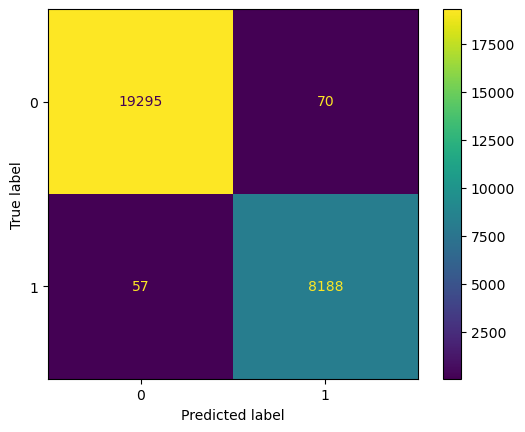

Time taken to cross-validate the Random Forest model: 90.05626249313354 seconds
Cross-validation scores: [0.99195943 0.99127128 0.96352639 0.97710891 0.99702995]
Mean CV accuracy: 0.9841791935186823
Standard deviation of CV accuracy: 0.012267837404248095


In [16]:
rf = RandomForestClassifier(random_state=0)
run_model('Random Forest', rf, X_train, X_test, y_train, y_test, X, y)

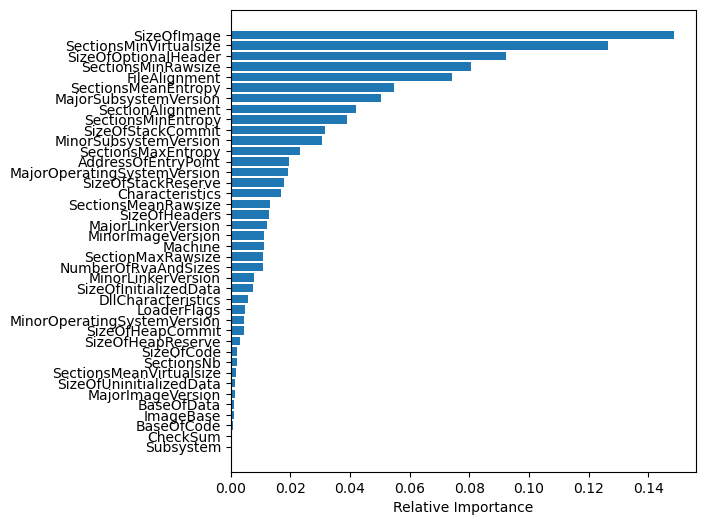

In [17]:
importances = (rf.feature_importances_)
i = np.argsort(importances)

plt.figure(figsize=(6,6))
plt.barh(range(len(i)), importances[i], align='center')
plt.yticks(range(len(i)), [df.columns[j] for j in i])
plt.xlabel('Relative Importance')
plt.show()

## Decision Tree
We run, train, and cross-validate a Decision Tree model. The model was faster to train compared to the Random Forest model with an accuracy of 99.2%. From cross-validation, the Decision Tree produces similar accuracies for each fold.

Decision Tree classifier:
Time taken to train the Decision Tree model: 2.038170576095581 seconds
Time taken to test the Decision Tree model: 0.008720636367797852 seconds
Accuracy: 0.9924664976457805
Precision: 0.9860892705939277
Recall: 0.9887204366282596
F1 score: 0.9874031007751938


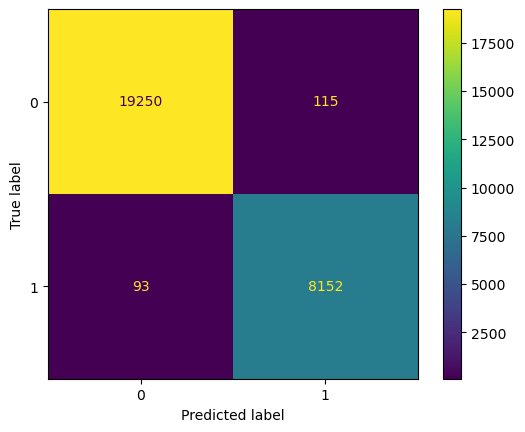

Time taken to cross-validate the Decision Tree model: 10.069631576538086 seconds
Cross-validation scores: [0.98391887 0.98859109 0.9521895  0.94331559 0.99558115]
Mean CV accuracy: 0.9727192400307135
Standard deviation of CV accuracy: 0.020909611664686092


In [18]:
dt = DecisionTreeClassifier(random_state=0)
run_model('Decision Tree', dt, X_train, X_test, y_train, y_test, X, y)

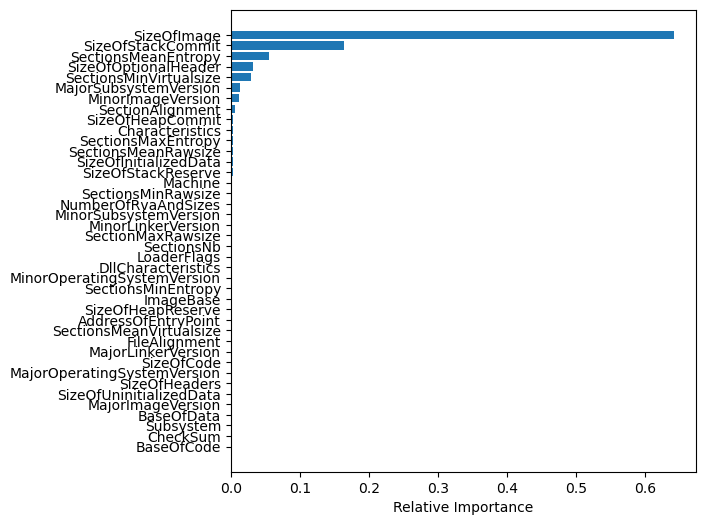

In [19]:
importances = (dt.feature_importances_)
i = np.argsort(importances)

plt.figure(figsize=(6,6))
plt.barh(range(len(i)), importances[i], align='center')
plt.yticks(range(len(i)), [df.columns[j] for j in i])
plt.xlabel('Relative Importance')
plt.show()

## Support Vector Machine
We run, train, and cross-validate a Support Vector Machine model. The model was significantly slower to train compared to the other models with an accuracy of 98.8%. The cross-validation took a long time to run, but produces similar accuracies for each fold.

Support Vector Machine classifier:
Time taken to train the Support Vector Machine model: 75.32770681381226 seconds
Time taken to test the Support Vector Machine model: 7.883122444152832 seconds
Accuracy: 0.9882651213328504
Precision: 0.9798861020235066
Recall: 0.9808368708308065
F1 score: 0.9803612559098073


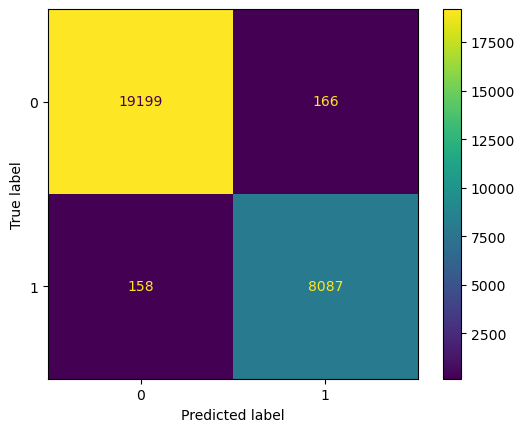

Time taken to cross-validate the Support Vector Machine model: 330.7418773174286 seconds
Cross-validation scores: [0.98703368 0.9882289  0.9707704  0.97370423 0.99420479]
Mean CV accuracy: 0.9827884004303957
Standard deviation of CV accuracy: 0.00899899909658159


In [20]:
svc_model = SVC(random_state=0)
run_model('Support Vector Machine', svc_model, X_train, X_test, y_train, y_test, X, y)

## Gradient Boost
We run, train, and cross-validate a Gradient Boost model. The model was slower to train compared to the other models except SVM with an accuracy of 99.0%. 

Gradient Boost classifier:
Time taken to train the Gradient Boost model: 37.90314698219299 seconds
Time taken to test the Gradient Boost model: 0.044208526611328125 seconds
Accuracy: 0.9902933719666788
Precision: 0.9849240121580547
Recall: 0.9825348696179502
F1 score: 0.9837279902853673


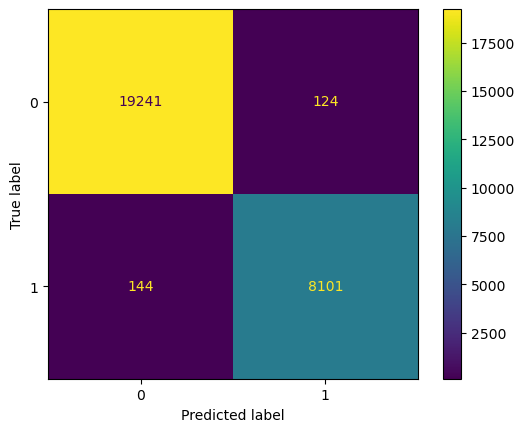

Time taken to cross-validate the Gradient Boost model: 180.73405003547668 seconds
Cross-validation scores: [0.98562115 0.98877218 0.98486001 0.97518925 0.99529139]
Mean CV accuracy: 0.985946797107206
Standard deviation of CV accuracy: 0.006516382603599847


In [21]:
gbc = GradientBoostingClassifier()
run_model('Gradient Boost', gbc, X_train, X_test, y_train, y_test, X, y)

## Gaussian Naive Bayes
Even though the Gaussian Naive Bayes model was quick to train, it is the most inaccurate with an accuracy of 52.0%. This could be because Gaussian Naive Bayes is a simple model with low capacity and cannot learn complex decision boundaries.

Gaussian Naive Bayes classifier:
Time taken to train the Gaussian Naive Bayes model: 0.10896849632263184 seconds
Time taken to test the Gaussian Naive Bayes model: 0.014802932739257812 seconds
Accuracy: 0.5201014125316914
Precision: 0.38340399757722593
Recall: 0.99805942995755
F1 score: 0.5539921906557156


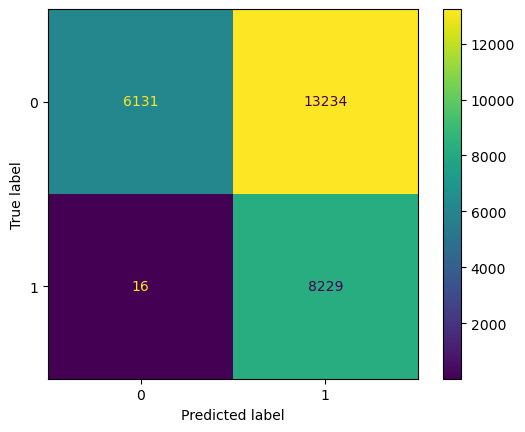

Time taken to cross-validate the Gaussian Naive Bayes model: 0.7164497375488281 seconds
Cross-validation scores: [0.47989859 0.47917421 0.55981745 0.53551378 0.47980731]
Mean CV accuracy: 0.5068422682980209
Standard deviation of CV accuracy: 0.034207595422023104


In [22]:
gnb = GaussianNB()
run_model('Gaussian Naive Bayes', gnb, X_train, X_test, y_train, y_test, X, y)

## Artificial Neural Network
We build an Artificial Neural Network with 1 input layer, 1 hidden layer with 64 units, and 1 output layer. We chose the 'relu' activation function for the hidden layers and use the adam optimizter and mean absolute error loss. We then train the model using batch size of 256 and 60 epochs. By implementing the early stopping optimization method, the model training will be stopped automatically when the model begins to overfit the data which is when the validation loss begins to increase. This happens at about 48 epochs with an accuracy of 98.9%, taking 63.9 seconds, which is shorter than the time it took the Random Forest model to train.

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_3 (Dense)             (None, 64)                2624      
                                                                 
 dense_4 (Dense)             (None, 64)                4160      
                                                                 
 dense_5 (Dense)             (None, 1)                 65        
                                                                 


Total params: 6,849
Trainable params: 6,849
Non-trainable params: 0
_________________________________________________________________
None
Epoch 1/60
432/432 [==============================] - 2s 3ms/step - loss: 0.0764 - accuracy: 0.9673 - val_loss: 0.0465 - val_accuracy: 0.9829
Epoch 2/60
432/432 [==============================] - 1s 2ms/step - loss: 0.0405 - accuracy: 0.9843 - val_loss: 0.0404 - val_accuracy: 0.9846
Epoch 3/60
432/432 [==============================] - 1s 2ms/step - loss: 0.0345 - accuracy: 0.9856 - val_loss: 0.0330 - val_accuracy: 0.9861
Epoch 4/60
432/432 [==============================] - 1s 3ms/step - loss: 0.0310 - accuracy: 0.9859 - val_loss: 0.0319 - val_accuracy: 0.9858
Epoch 5/60
432/432 [==============================] - 1s 3ms/step - loss: 0.0296 - accuracy: 0.9860 - val_loss: 0.0293 - val_accuracy: 0.9859
Epoch 6/60
432/432 [==============================] - 1s 3ms/step - loss: 0.0270 - accuracy: 0.9862 - val_loss: 0.0308 - val_accuracy: 0.9854
Epoch 7/6

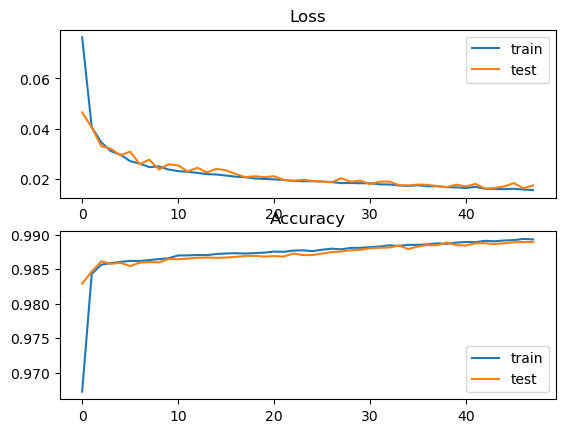

In [24]:
from keras import callbacks
input_shape = [X_train.shape[1]]

model = tf.keras.Sequential([
    tf.keras.layers.Dense(units=64, activation='relu', input_shape=input_shape),
    tf.keras.layers.Dense(units=64, activation='relu'),
    tf.keras.layers.Dense(units=1)
])

model.build()

print(model.summary())
start_time_train = time.time()  # Start time

model.compile(optimizer='adam', loss='mae', metrics=['accuracy'])  
earlystopping = callbacks.EarlyStopping(monitor="val_loss",
                                        mode="min",
                                        patience=5,
                                        restore_best_weights=True)

history = model.fit(X_train, y_train, validation_data=(X_test,y_test), batch_size=256, epochs=60,callbacks=[earlystopping])
    
end_time_train = time.time()  # End time
time_taken_train = end_time_train - start_time_train  # Time taken to run the code

print(f"Time taken to train the Artificial Neural Network: {time_taken_train} seconds")
# plot loss during training
pyplot.subplot(211)
pyplot.title('Loss')
pyplot.plot(history.history['loss'], label='train')
pyplot.plot(history.history['val_loss'], label='test')
pyplot.legend()
# plot accuracy during training
pyplot.subplot(212)
pyplot.title('Accuracy')
pyplot.plot(history.history['accuracy'], label='train')
pyplot.plot(history.history['val_accuracy'], label='test')
pyplot.legend()
pyplot.show()

In [25]:
accuracy = history.history['accuracy'][11]

accuracies.loc[len(accuracies.index)] = ['ANN', accuracy, 0, 0, 0]
times.loc[len(times.index)] = ['ANN',time_taken_train, time_taken_train]

<Axes: xlabel='Model'>

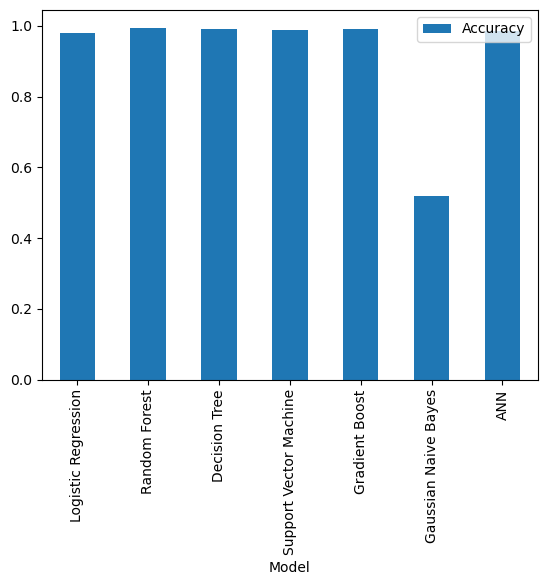

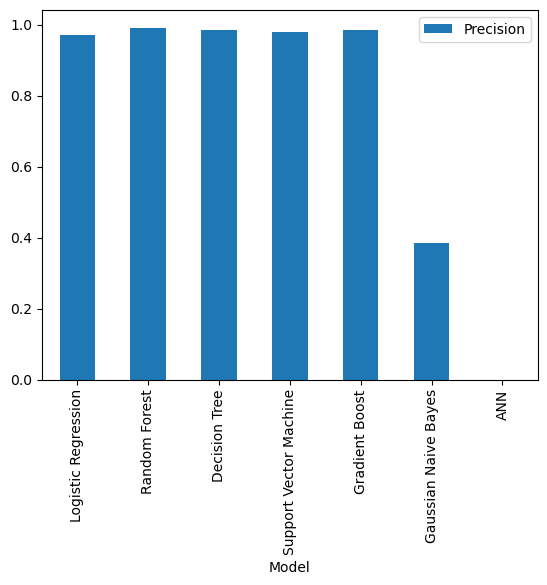

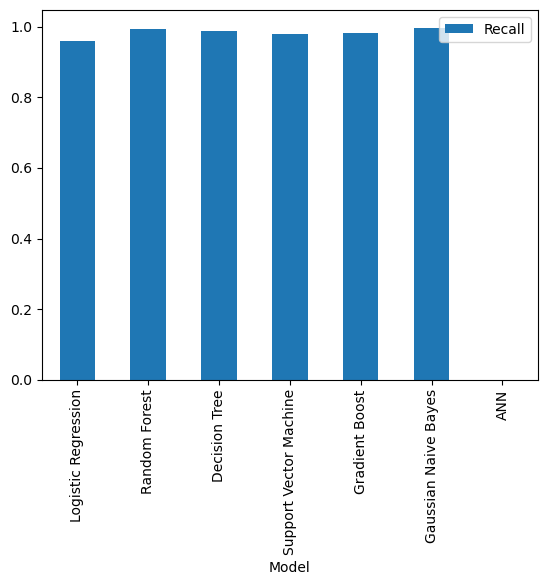

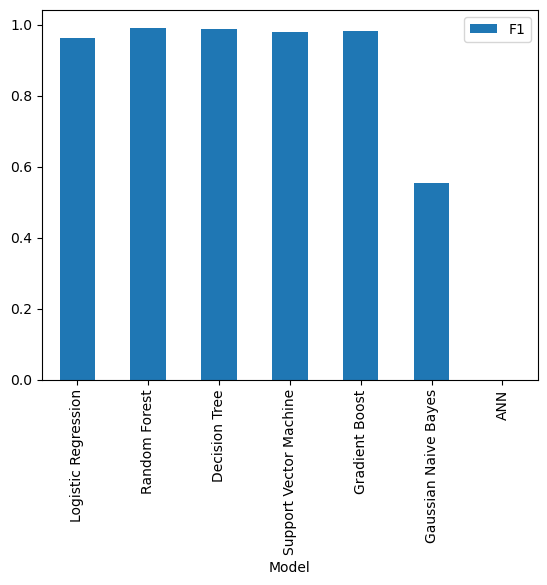

In [26]:
accuracies.plot(kind='bar', x='Model', y='Accuracy')
accuracies.plot(kind='bar', x='Model', y='Precision')
accuracies.plot(kind='bar', x='Model', y='Recall')
accuracies.plot(kind='bar', x='Model', y='F1')

In [27]:
print(times)

                    Model      Train       Test
0     Logistic Regression   0.301832   0.005455
1           Random Forest  19.356451   0.241312
2           Decision Tree   2.038171   0.008721
3  Support Vector Machine  75.327707   7.883122
4          Gradient Boost  37.903147   0.044209
5    Gaussian Naive Bayes   0.108968   0.014803
6                     ANN  63.904171  63.904171


In [15]:
import sys
import unittest

class TestRunModel(unittest.TestCase):
    def test_df_shape(self):
        df = pd.read_csv('MalwareData.csv', sep='|')
        self.assertEqual(df.shape, (138047, 57))
        df = df.drop(columns=['Name', 'md5'])
        self.assertEqual(df.shape, (138047, 55))
    def test_value_counts(self):
        df = pd.read_csv('MalwareData.csv', sep='|')
        self.assertEqual(df['legitimate'].value_counts()[0], 96724)
        self.assertEqual(df['legitimate'].value_counts()[1], 41323)
    # def test_normalization(self):
    #     df = pd.read_csv('MalwareData.csv', sep='|').drop(columns=['Name', 'md5'])
    #     X = df.drop(columns=['legitimate'])
    #     for i in X.columns:
    #         zscore_normalization(X, i)
    #     for label, content in X.describe().items():
    #         self.assertAlmostEqual(content['mean'], 0)
    #         self.assertAlmostEqual(content['std'], 1)
    def test_components_drop(self):
        df = pd.read_csv('MalwareData.csv', sep='|').drop(columns=['Name', 'md5'])
        X = df.drop(columns=['legitimate'])
        cols_to_drop = []
        correlation_matrix = X.corr()
        for i in X.columns:
            for j in X.columns:
                if i != j:
                    if abs(correlation_matrix[i][j]) > 0.6 and i not in cols_to_drop and j not in cols_to_drop:
                        cols_to_drop.append(i)
        cols_to_drop = set(cols_to_drop)
        X.drop(columns=cols_to_drop, inplace=True)
        self.assertEqual(len(X.columns), 40)
    def test_gbc_training(self):
        df = pd.read_csv('MalwareData.csv', sep='|').drop(columns=['Name', 'md5'])
        X = df.drop(columns=['legitimate'])
        y = df['legitimate']
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20)
        model = GradientBoostingClassifier(random_state=42)
        model.fit(X_train, y_train)
        self.assertIsNotNone(model)
        self.assertTrue(hasattr(model, 'feature_importances_'))
    def test_gbc_prediction(self):
        df = pd.read_csv('MalwareData.csv', sep='|').drop(columns=['Name', 'md5'])
        X = df.drop(columns=['legitimate'])
        y = df['legitimate']
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20)
        model = GradientBoostingClassifier(random_state=42)
        model.fit(X_train, y_train)
        predictions = model.predict(X_test)
        self.assertEqual(len(predictions), len(X_test))
    def test_gbc_accuracy(self):
        df = pd.read_csv('MalwareData.csv', sep='|').drop(columns=['Name', 'md5'])
        X = df.drop(columns=['legitimate'])
        y = df['legitimate']
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20)
        model = GradientBoostingClassifier(random_state=42)
        model.fit(X_train, y_train)
        predictions = model.predict(X_test)
        accuracy = accuracy_score(y_test, predictions)
        self.assertGreater(accuracy, 0.9)
    def test_nb_training(self):
        df = pd.read_csv('MalwareData.csv', sep='|').drop(columns=['Name', 'md5'])
        X = df.drop(columns=['legitimate'])
        y = df['legitimate']
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20)
        model = GaussianNB()
        model.fit(X_train, y_train)
        self.assertIsNotNone(model)
        self.assertTrue(hasattr(model, 'class_prior_'))
    def test_nb_prediction(self):
        df = pd.read_csv('MalwareData.csv', sep='|').drop(columns=['Name', 'md5'])
        X = df.drop(columns=['legitimate'])
        y = df['legitimate']
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20)
        model = GaussianNB()
        model.fit(X_train, y_train)
        predictions = model.predict(X_test)
        self.assertEqual(len(predictions), len(X_test))
    def test_nb_accuracy(self):
        df = pd.read_csv('MalwareData.csv', sep='|').drop(columns=['Name', 'md5'])
        X = df.drop(columns=['legitimate'])
        y = df['legitimate']
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20)
        model = GaussianNB()
        model.fit(X_train, y_train)
        predictions = model.predict(X_test)
        accuracy = accuracy_score(y_test, predictions)
        self.assertGreater(accuracy, 0.9)
    def test_ann_training(self):
        df = pd.read_csv('MalwareData.csv', sep='|').drop(columns=['Name', 'md5'])
        X = df.drop(columns=['legitimate'])
        y = df['legitimate']
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20)
        self.model = Sequential([
            Dense(64, input_dim=20, activation='relu'),
            Dense(32, activation='relu'),
            Dense(1, activation='sigmoid')
        ])
        self.model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
        model.fit(X_train, y_train)
        self.assertIsNotNone(model)
        self.assertTrue(hasattr(model, 'class_prior_'))
    def test_ann_prediction(self):
        df = pd.read_csv('MalwareData.csv', sep='|').drop(columns=['Name', 'md5'])
        X = df.drop(columns=['legitimate'])
        y = df['legitimate']
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20)
        self.model = Sequential([
            Dense(64, input_dim=20, activation='relu'),
            Dense(32, activation='relu'),
            Dense(1, activation='sigmoid')
        ])
        self.model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
        model.fit(X_train, y_train)
        predictions = model.predict(X_test)
        self.assertEqual(len(predictions), len(X_test))
    def test_ann_accuracy(self):
        df = pd.read_csv('MalwareData.csv', sep='|').drop(columns=['Name', 'md5'])
        X = df.drop(columns=['legitimate'])
        y = df['legitimate']
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20)
        self.model = Sequential([
            Dense(64, input_dim=20, activation='relu'),
            Dense(32, activation='relu'),
            Dense(1, activation='sigmoid')
        ])
        self.model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
        model.fit(X_train, y_train)
        predictions = model.predict(X_test)
        accuracy = accuracy_score(y_test, predictions)
        self.assertGreater(accuracy, 0.9)
    

if __name__ == '__main__':
    main = TestRunModel()
    suite = unittest.TestLoader().loadTestsFromTestCase(TestRunModel)
    unittest.TextTestRunner(verbosity=4,stream=sys.stderr).run(suite)

test_components_drop (__main__.TestRunModel.test_components_drop) ... ok
test_df_shape (__main__.TestRunModel.test_df_shape) ... ok
test_gbc_accuracy (__main__.TestRunModel.test_gbc_accuracy) ... ok
test_gbc_prediction (__main__.TestRunModel.test_gbc_prediction) ... ok
test_gbc_training (__main__.TestRunModel.test_gbc_training) ... ok
test_nb_accuracy (__main__.TestRunModel.test_nb_accuracy) ... FAIL
test_nb_prediction (__main__.TestRunModel.test_nb_prediction) ... ok
test_nb_training (__main__.TestRunModel.test_nb_training) ... ok
test_value_counts (__main__.TestRunModel.test_value_counts) ... ok

FAIL: test_nb_accuracy (__main__.TestRunModel.test_nb_accuracy)
----------------------------------------------------------------------
Traceback (most recent call last):
  File "C:\Users\ConnorMullikin\AppData\Local\Temp\ipykernel_37576\3526329114.py", line 90, in test_nb_accuracy
    self.assertGreater(accuracy, 0.9)
AssertionError: 0.6973560304237595 not greater than 0.9

-----------------

In [111]:
class TestANN(unittest.TestCase):
    def setUp(self):
        # Create a synthetic dataset (as a stand-in for malware data)
        self.X, self.y = make_classification(n_samples=1000, n_features=20, random_state=42, n_classes=2)
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(self.X, self.y, test_size=0.2, random_state=42)
        # Initialize the model
        self.model = Sequential([
            Dense(64, input_dim=20, activation='relu'),
            Dense(32, activation='relu'),
            Dense(1, activation='sigmoid')
        ])
        self.model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    def test_training(self):
        # Train the model
        self.model.fit(self.X_train, self.y_train, epochs=10, batch_size=32, verbose=0)
        # Check if the model has been trained
        self.assertIsNotNone(self.model)
    def test_prediction(self):
        # Train the model
        self.model.fit(self.X_train, self.y_train, epochs=10, batch_size=32, verbose=0)
        # Make predictions
        predictions = (self.model.predict(self.X_test) > 0.5).astype("int32")
        # Check if predictions are made
        self.assertEqual(len(predictions), len(self.X_test))
    def test_accuracy(self):
        # Train the model
        self.model.fit(self.X_train, self.y_train, epochs=10, batch_size=32, verbose=0)
        # Make predictions
        predictions = (self.model.predict(self.X_test) > 0.5).astype("int32")
        # Calculate accuracy
        accuracy = accuracy_score(self.y_test, predictions)
        # Check if accuracy is reasonable
        self.assertGreater(accuracy, 0.7)
    def test_precision_and_recall(self):
        # Train the model
        self.model.fit(self.X_train, self.y_train, epochs=10, batch_size=32, verbose=0)
        # Make predictions
        predictions = (self.model.predict(self.X_test) > 0.5).astype("int32")
        # Calculate precision and recall
        precision = precision_score(self.y_test, predictions)
        recall = recall_score(self.y_test, predictions)
        # Check if precision and recall are reasonable
        self.assertGreater(precision, 0.7)
        self.assertGreater(recall, 0.7)

In [112]:
class TestSVM(unittest.TestCase):
    def setUp(self):
        # Create a synthetic dataset
        self.X, self.y = make_classification(n_samples=1000, n_features=20, random_state=42)
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(self.X, self.y, test_size=0.2, random_state=42)
        # Initialize the model
        self.model = SVC(random_state=42)
    def test_training(self):
        # Train the model
        self.model.fit(self.X_train, self.y_train)
        # Check if the model has been trained
        self.assertIsNotNone(self.model)
        self.assertTrue(hasattr(self.model, 'feature_importances_'))
    def test_prediction(self):
        # Train the model
        self.model.fit(self.X_train, self.y_train)
        # Make predictions
        predictions = self.model.predict(self.X_test)
        # Check if predictions are made
        self.assertEqual(len(predictions), len(self.X_test))
    def test_accuracy(self):
        # Train the model
        self.model.fit(self.X_train, self.y_train)
        # Make predictions
        predictions = self.model.predict(self.X_test)
        # Calculate accuracy
        accuracy = accuracy_score(self.y_test, predictions)
        # Check if accuracy is reasonable
        self.assertGreater(accuracy, 0.7)

In [113]:
class TestLogisticRegression(unittest.TestCase):
    def setUp(self):
        # Create a synthetic dataset
        self.X, self.y = make_classification(n_samples=1000, n_features=20, random_state=42)
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(self.X, self.y, test_size=0.2, random_state=42)
        # Initialize the model
        self.model = LogisticRegression(random_state=42)
    def test_training(self):
        # Train the model
        self.model.fit(self.X_train, self.y_train)
        # Check if the model has been trained
        self.assertIsNotNone(self.model)
        self.assertTrue(hasattr(self.model, 'feature_importances_'))
    def test_prediction(self):
        # Train the model
        self.model.fit(self.X_train, self.y_train)
        # Make predictions
        predictions = self.model.predict(self.X_test)
        # Check if predictions are made
        self.assertEqual(len(predictions), len(self.X_test))
    def test_accuracy(self):
        # Train the model
        self.model.fit(self.X_train, self.y_train)
        # Make predictions
        predictions = self.model.predict(self.X_test)
        # Calculate accuracy
        accuracy = accuracy_score(self.y_test, predictions)
        # Check if accuracy is reasonable
        self.assertGreater(accuracy, 0.7)

In [114]:
class TestRandomForest(unittest.TestCase):
    def setUp(self):
        # Create a synthetic dataset
        self.X, self.y = make_classification(n_samples=1000, n_features=20, random_state=42)
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(self.X, self.y, test_size=0.2, random_state=42)
        # Initialize the model
        self.model = RandomForest(random_state=42)
    def test_training(self):
        # Train the model
        self.model.fit(self.X_train, self.y_train)
        # Check if the model has been trained
        self.assertIsNotNone(self.model)
        self.assertTrue(hasattr(self.model, 'feature_importances_'))
    def test_prediction(self):
        # Train the model
        self.model.fit(self.X_train, self.y_train)
        # Make predictions
        predictions = self.model.predict(self.X_test)
        # Check if predictions are made
        self.assertEqual(len(predictions), len(self.X_test))
    def test_accuracy(self):
        # Train the model
        self.model.fit(self.X_train, self.y_train)
        # Make predictions
        predictions = self.model.predict(self.X_test)
        # Calculate accuracy
        accuracy = accuracy_score(self.y_test, predictions)
        # Check if accuracy is reasonable
        self.assertGreater(accuracy, 0.7)

In [115]:
class TestDecisionTree(unittest.TestCase):
    def setUp(self):
        # Create a synthetic dataset
        self.X, self.y = make_classification(n_samples=1000, n_features=20, random_state=42)
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(self.X, self.y, test_size=0.2, random_state=42)
        # Initialize the model
        self.model = DecisionTreeClassifier(random_state=42)
    def test_training(self):
        # Train the model
        self.model.fit(self.X_train, self.y_train)
        # Check if the model has been trained
        self.assertIsNotNone(self.model)
        self.assertTrue(hasattr(self.model, 'feature_importances_'))
    def test_prediction(self):
        # Train the model
        self.model.fit(self.X_train, self.y_train)
        # Make predictions
        predictions = self.model.predict(self.X_test)
        # Check if predictions are made
        self.assertEqual(len(predictions), len(self.X_test))
    def test_accuracy(self):
        # Train the model
        self.model.fit(self.X_train, self.y_train)
        # Make predictions
        predictions = self.model.predict(self.X_test)
        # Calculate accuracy
        accuracy = accuracy_score(self.y_test, predictions)
        # Check if accuracy is reasonable
        self.assertGreater(accuracy, 0.7)
        # from your_notebook import run_model  # Import the run_model function